<a href="https://colab.research.google.com/github/sahar-mariam/kannada-sentiment-analysis/blob/main/ensemble_model_phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platf

In [ ]:
import json
import pandas as pd
from datasets import Dataset

file_path = "/content/ksa-modified.jsonl"
data = [json.loads(line) for line in open(file_path, "r")]

# Filter invalid samples
data = [sample for sample in data if sample.get("en") and sample.get("label") in ["negative", "neutral", "positive"]]

# Convert to DataFrame and map labels
df = pd.DataFrame(data)
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
df["label"] = df["label"].map(label2id)

# Create Huggingface Dataset
dataset = Dataset.from_pandas(df[["en", "label"]].rename(columns={"en": "text"}))
dataset = dataset.train_test_split(test_size=0.2, seed=42)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
import numpy as np
import evaluate
from sklearn.metrics import classification_report

def tokenize_dataset(tokenizer, dataset):
    return dataset.map(
        lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=128),
        batched=True
    )

def compute_metrics(eval_pred):
    metric = evaluate.load("accuracy")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric.compute(predictions=predictions, references=labels)
    report = classification_report(labels, predictions, output_dict=True, zero_division=0)
    return {
        "accuracy": acc["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }

def train_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

    tokenized = tokenize_dataset(tokenizer, dataset)
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    args = TrainingArguments(
        output_dir=f"./results/{model_name.replace('/', '_')}",
        eval_strategy="epoch",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        logging_dir='./logs',
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate()
    preds = trainer.predict(tokenized["test"]).predictions
    return model, tokenizer, metrics, preds


In [ ]:
models = {
    "MuRIL": "google/muril-base-cased",
    "XLM-R": "xlm-roberta-base",
    "IndicBERT": "ai4bharat/indic-bert",
    "DistilBERT": "distilbert-base-multilingual-cased",
    "mBERT": "bert-base-multilingual-cased"
}

trained_models = {}
metrics_dict = {}
predictions_dict = {}

for name, model_name in models.items():
    print(f"\nTraining {name}...\n")
    model, tokenizer, metrics, preds = train_model(model_name)
    trained_models[name] = (model, tokenizer)
    metrics_dict[name] = metrics
    predictions_dict[name] = preds
    print(f"✅ {name} Metrics: {metrics}")



Training MuRIL...



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/673 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.923475,0.798817,0.836280,0.798817,0.790822
2,No log,0.805922,0.863905,0.866654,0.863905,0.861907


...

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/673 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.757448,0.710059,0.776555,0.710059,0.702341
2,No log,0.481748,0.857988,0.860195,0.857988,0.857923


In [ ]:
# Create metrics DataFrame
metrics_df = pd.DataFrame(metrics_dict).T

# Calculate ensemble performance on test set
all_preds = []
for name, logits in predictions_dict.items():
    preds = np.argmax(logits, axis=-1)
    all_preds.append(preds)

# Majority voting
all_preds = np.array(all_preds)
ensemble_preds = mode(all_preds, axis=0, keepdims=True).mode[0]
true_labels = dataset["test"]["label"]

# Generate classification report for ensemble
ensemble_report = classification_report(
    true_labels, ensemble_preds, target_names=label2id.keys(), output_dict=True, zero_division=0
)

ensemble_metrics = {
    "accuracy": np.mean(ensemble_preds == true_labels),
    "precision": ensemble_report["weighted avg"]["precision"],
    "recall": ensemble_report["weighted avg"]["recall"],
    "f1": ensemble_report["weighted avg"]["f1-score"],
}

# Combine with metrics_df
ensemble_metrics_df = pd.DataFrame([ensemble_metrics], index=["Ensemble"])
comparison_df = pd.concat([metrics_df, ensemble_metrics_df])

# Show metric comparison
print("\n📊 Accuracy, Precision, Recall, F1 Score Comparison:")
display(comparison_df.round(4))



📊 Accuracy, Precision, Recall, F1 Score Comparison:


,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,accuracy,precision,recall,f1
MuRIL,0.8059,0.8639,0.8667,0.8639,0.8619,2.5331,66.716,8.685,2.0,NaN,NaN,NaN,NaN
XLM-R,0.4460,0.8462,0.8479,0.8462,0.8449,2.5211,67.033,8.726,2.0,NaN,NaN,NaN,NaN
IndicBERT,0.7047,0.8047,0.8242,0.8047,0.8035,2.5591,66.038,8.597,2.0,NaN,NaN,NaN,NaN
DistilBERT,0.4714,0.8047,0.8096,0.8047,0.8047,2.6410,63.991,8.330,2.0,NaN,NaN,NaN,NaN
mBERT,0.4817,0.8580,0.8602,0.8580,0.8579,2.3779,71.071,9.252,2.0,NaN,NaN,NaN,NaN
Ensemble,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8876,0.8897,0.8876,0.8869


In [ ]:
import torch.nn.functional as F
from scipy.stats import mode
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

# Label mappings
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

# 🎤 Take user input
user_input = input("Enter a sentence to analyze sentiment: ")

# 🧠 Step 1: Get predictions and softmax probabilities
softmax_outputs = {}
predictions = {}
votes = []

for name, (model, tokenizer) in trained_models.items():
    inputs = tokenizer(user_input, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_id = int(np.argmax(probs))
        predictions[name] = (id2label[pred_id], probs[pred_id])
        softmax_outputs[name] = probs
        votes.append(pred_id)

# 🧠 Step 2: Ensemble - Voting
voting_pred = int(mode(votes, keepdims=True).mode[0])
voting_label = id2label[voting_pred]
voting_conf = np.mean([softmax_outputs[m][voting_pred] for m in softmax_outputs if np.argmax(softmax_outputs[m]) == voting_pred])

# 🧠 Step 3: Ensemble - Bagging (avg softmax)
avg_probs = np.mean(list(softmax_outputs.values()), axis=0)
bagging_pred = int(np.argmax(avg_probs))
bagging_label = id2label[bagging_pred]
bagging_conf = avg_probs[bagging_pred]

# 🖨️ Step 4: Display predictions + confidences
print("\n📋 Model Predictions:")
for name, (label, conf) in predictions.items():
    print(f"{name}: {label} ({conf*100:.2f}%)")

print(f"\n🗳️ Voting Ensemble: {voting_label} ({voting_conf*100:.2f}%)")
print(f"🪵 Bagging Ensemble: {bagging_label} ({bagging_conf*100:.2f}%)")


Enter a sentence to analyze sentiment: ನಾನು ವೆಬ್‌ಸೈಟ್‌ನಿಂದ ಆರ್ಡರ್ ಮಾಡಿದ ಟೇಬಲ್ ಹಾನಿಗೊಳಗಾಗಿದೆ. ಅದನ್ನು ಹಿಂತಿರುಗಿಸಲು ನನಗೆ ಇಷ್ಟವಿಲ್ಲ.

📋 Model Predictions:
MuRIL: negative (51.93%)
XLM-R: negative (90.23%)
IndicBERT: positive (37.53%)
DistilBERT: neutral (91.49%)
mBERT: neutral (97.61%)

🗳️ Voting Ensemble: negative (71.08%)
🪵 Bagging Ensemble: neutral (51.67%)


In [ ]:
# Evaluate each model
all_preds = {}
true_labels = dataset["test"]["label"]

for name, logits in predictions_dict.items():
    pred = np.argmax(logits, axis=-1)
    all_preds[name] = pred

# Evaluate voting ensemble
model_preds_matrix = np.array(list(all_preds.values()))
voting_ensemble_preds = mode(model_preds_matrix, axis=0, keepdims=True).mode[0]

# Evaluate bagging ensemble
softmax_matrix = []
for name, logits in predictions_dict.items():
    softmax_matrix.append(F.softmax(torch.tensor(logits), dim=1).numpy())
bagging_probs = np.mean(softmax_matrix, axis=0)
bagging_ensemble_preds = np.argmax(bagging_probs, axis=-1)

# Step 6: Create final metrics dict
def extract_metrics(name, preds):
    report = classification_report(true_labels, preds, output_dict=True, zero_division=0)
    return {
        "accuracy": np.mean(preds == true_labels),
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }

metrics_summary = {}

# For each model
for name in all_preds:
    metrics_summary[name] = extract_metrics(name, all_preds[name])

# For ensemble models
metrics_summary["VotingEnsemble"] = extract_metrics("VotingEnsemble", voting_ensemble_preds)
metrics_summary["BaggingEnsemble"] = extract_metrics("BaggingEnsemble", bagging_ensemble_preds)

# 📊 Convert to DataFrame
metrics_df = pd.DataFrame(metrics_summary).T


<ipython-input-30-90ff21ecb151>:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


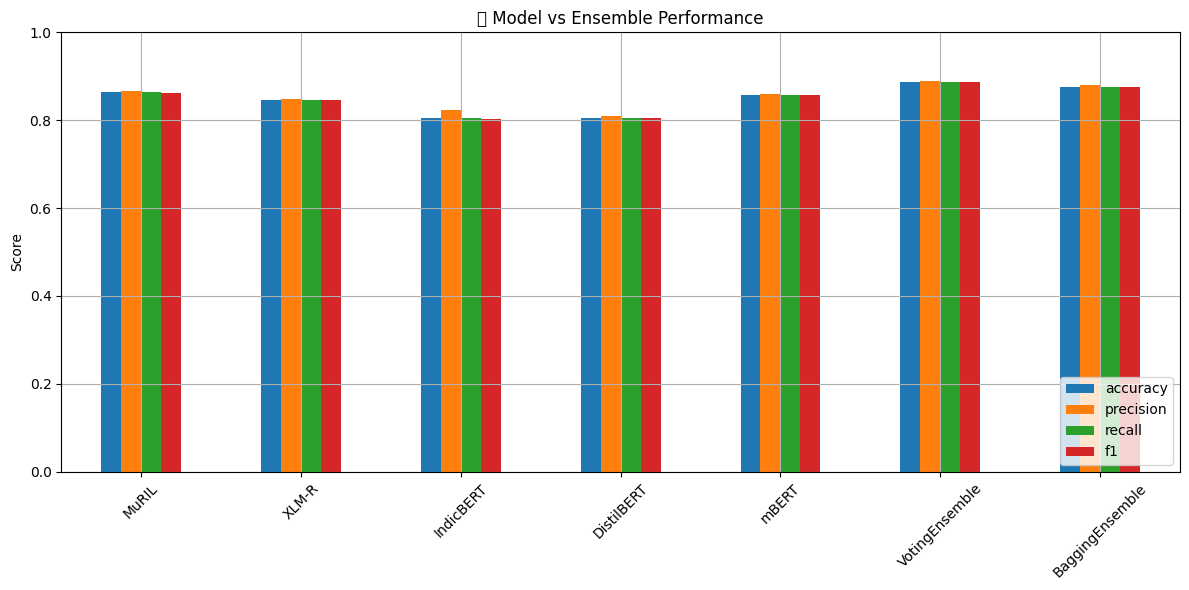

In [ ]:
# 📈 Compare Accuracy, Precision, Recall, F1
plt.figure(figsize=(12, 6))
metrics_df[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(12, 6))
plt.title("📊 Model vs Ensemble Performance")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import display

# 📋 Display evaluation metrics table
print("📊 Evaluation Metrics: Accuracy, Precision, Recall, F1 (on test set)\n")
display(metrics_df.round(4))  # Round to 4 decimal places for readability


📊 Evaluation Metrics: Accuracy, Precision, Recall, F1 (on test set)



,accuracy,precision,recall,f1
MuRIL,0.8639,0.8667,0.8639,0.8619
XLM-R,0.8462,0.8479,0.8462,0.8449
IndicBERT,0.8047,0.8242,0.8047,0.8035
DistilBERT,0.8047,0.8096,0.8047,0.8047
mBERT,0.8580,0.8602,0.8580,0.8579
VotingEnsemble,0.8876,0.8897,0.8876,0.8869
BaggingEnsemble,0.8757,0.8806,0.8757,0.8748


In [ ]:
!pip install langdetect --quiet


🔤 Language-Adaptive Hybrid Input
Enter English sentence: i like to go to the beach
Enter Kannada sentence: ನನಗೆ ಬೀಚ್‌ಗೆ ಹೋಗುವುದು ಇಷ್ಟ.

📋 Language-Adaptive Predictions (En + Kn)
MuRIL: neutral (45.54%)
XLM-R: neutral (97.60%)
IndicBERT: positive (42.22%)
DistilBERT: neutral (93.74%)
mBERT: neutral (97.80%)
VotingEnsemble: neutral (83.67%)
BaggingEnsemble: neutral (73.28%)


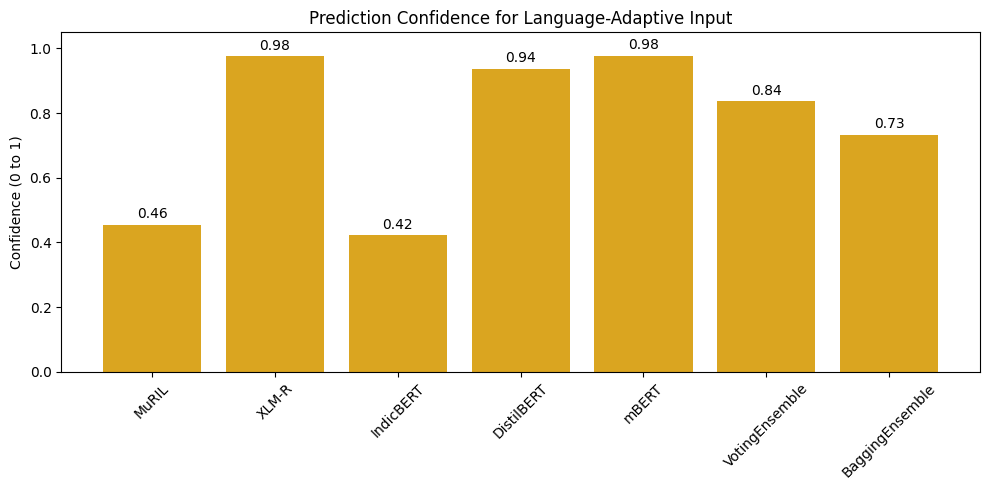

In [ ]:
from langdetect import detect
import torch.nn.functional as F
from scipy.stats import mode
import matplotlib.pyplot as plt

# 🧠 Predict using both en+kn hybrid input
def predict_hybrid(text_en, text_kn):
    combined_input = text_en.strip() + " [SEP] " + text_kn.strip()

    predictions = {}
    confidences = {}
    all_softmax = []
    vote_ids = []

    for name, (model, tokenizer) in trained_models.items():
        inputs = tokenizer(combined_input, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            pred_id = int(np.argmax(probs))
            predictions[name] = (id2label[pred_id], probs[pred_id])
            confidences[name] = probs
            all_softmax.append(probs)
            vote_ids.append(pred_id)

    # Voting Ensemble
    voting_pred = int(mode(vote_ids, keepdims=True).mode[0])
    voting_label = id2label[voting_pred]
    voting_conf = np.mean([confidences[m][voting_pred] for m in confidences if np.argmax(confidences[m]) == voting_pred])

    # Bagging Ensemble
    avg_probs = np.mean(all_softmax, axis=0)
    bagging_pred = int(np.argmax(avg_probs))
    bagging_label = id2label[bagging_pred]
    bagging_conf = avg_probs[bagging_pred]

    predictions["VotingEnsemble"] = (voting_label, voting_conf)
    predictions["BaggingEnsemble"] = (bagging_label, bagging_conf)

    return predictions

# 🎤 Take hybrid input
print("\n🔤 Language-Adaptive Hybrid Input")
text_en = input("Enter English sentence: ")
text_kn = input("Enter Kannada sentence: ")

# 🔍 Predict
results = predict_hybrid(text_en, text_kn)

# 🖨️ Show predictions
print("\n📋 Language-Adaptive Predictions (En + Kn)")
for model, (label, conf) in results.items():
    print(f"{model}: {label} ({conf*100:.2f}%)")

# 📊 Optional: Visualize confidence
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), [conf for _, conf in results.values()], color="goldenrod")
plt.title("Prediction Confidence for Language-Adaptive Input")
plt.ylabel("Confidence (0 to 1)")
plt.ylim(0, 1.05)
for i, (_, conf) in enumerate(results.values()):
    plt.text(i, conf + 0.02, f"{conf:.2f}", ha="center")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import torch.nn.functional as F
from sklearn.metrics import classification_report
from scipy.stats import mode
import matplotlib.pyplot as plt

# 📌 Use true labels
true_labels = dataset["test"]["label"]

# 📌 Define function to compute metrics
def compute_metrics(name, preds):
    report = classification_report(true_labels, preds, output_dict=True, zero_division=0)
    return {
        "accuracy": np.mean(preds == true_labels),
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"]
    }

# 📌 Step 1: Get predictions from all 5 models
all_model_preds = {}
all_softmax_outputs = {}

for name, logits in predictions_dict.items():
    pred_ids = np.argmax(logits, axis=-1)
    all_model_preds[name] = pred_ids
    probs = F.softmax(torch.tensor(logits), dim=1).numpy()
    all_softmax_outputs[name] = probs

# Step 2: Identify top 3 models by F1
f1_scores = {
    model: compute_metrics(model, pred)["f1"]
    for model, pred in all_model_preds.items()
}
top_3_models = sorted(f1_scores, key=f1_scores.get, reverse=True)[:3]
best_model = max(f1_scores, key=f1_scores.get)

# 🔢 Utility: Get majority vote and avg softmax
def get_voting_ensemble(pred_dict):
    preds = np.array(list(pred_dict.values()))
    return mode(preds, axis=0, keepdims=True).mode[0]

def get_bagging_ensemble(softmax_dict):
    avg_probs = np.mean(list(softmax_dict.values()), axis=0)
    return np.argmax(avg_probs, axis=-1)

# 📊 Run evaluation for all setups
ablations = {}

# 1. All 5 models + ensembles
ablations["All5_Voting"] = compute_metrics("All5_Voting", get_voting_ensemble(all_model_preds))
ablations["All5_Bagging"] = compute_metrics("All5_Bagging", get_bagging_ensemble(all_softmax_outputs))

# 2. Top 3 models only
top3_preds = {k: all_model_preds[k] for k in top_3_models}
top3_softmax = {k: all_softmax_outputs[k] for k in top_3_models}
ablations["Top3_Voting"] = compute_metrics("Top3_Voting", get_voting_ensemble(top3_preds))
ablations["Top3_Bagging"] = compute_metrics("Top3_Bagging", get_bagging_ensemble(top3_softmax))

# 3. Best single model only
ablations["Best_Model"] = compute_metrics(best_model, all_model_preds[best_model])

# 🔍 Convert to DataFrame
ablation_df = pd.DataFrame(ablations).T
ablation_df.index.name = "Setup"
print("\n📋 Ablation Study Table:")
display(ablation_df.round(4))



📋 Ablation Study Table:


,accuracy,precision,recall,f1
Setup,,,,
All5_Voting,0.8876,0.8897,0.8876,0.8869
All5_Bagging,0.8757,0.8806,0.8757,0.8748
Top3_Voting,0.8757,0.8774,0.8757,0.8749
Top3_Bagging,0.8817,0.8857,0.8817,0.8809
Best_Model,0.8639,0.8667,0.8639,0.8619


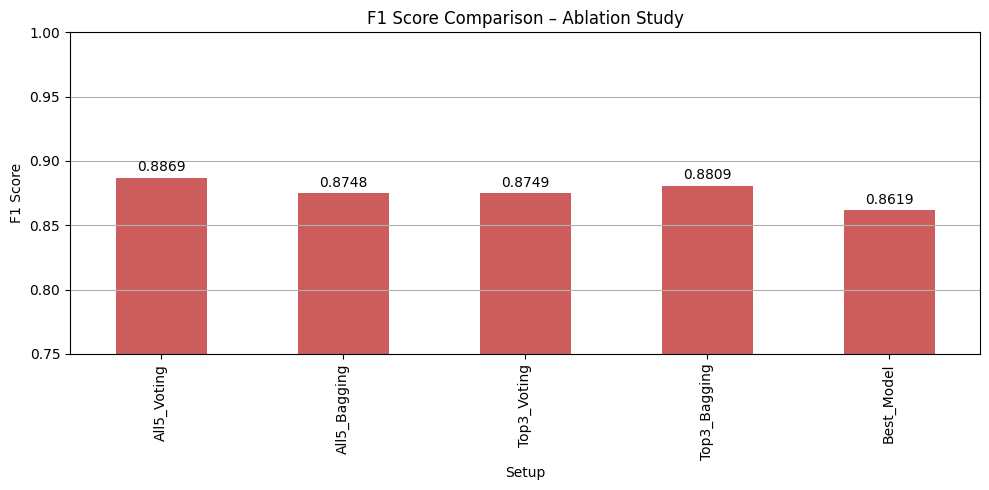

In [ ]:
# 📈 Visual F1 comparison
plt.figure(figsize=(10, 5))
ablation_df["f1"].plot(kind="bar", color="indianred")
plt.title("F1 Score Comparison – Ablation Study")
plt.ylabel("F1 Score")
plt.ylim(0.75, 1.00)
plt.grid(axis="y")
for i, v in enumerate(ablation_df["f1"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
